In [2]:
import os
import glob
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
#!pip install statsmodels
#!pip install matplotlib
import statsmodels.api as sm

In [ ]:
# Set the folder containing all your CSVs
#folder_path = 'residuals_technology'  # ← or your full path if not in current directory
#folder_path = 'residuals_uti'  # ← or your full path if not in current directory
#folder_path = 'residuals_hc'  # ← or your full path if not in current directory
#folder_path = 'residuals_e'  # ← or your full path if not in current directory
folder_path = 'residuals_RE'  # ← or your full path if not in current directory
sort_column = 'Residual'     # ← replace with the name of the column to sort by (e.g., 'daily_return')

# Store all dataframes
all_dfs = []

# Process each file
for filepath in glob.glob(os.path.join(folder_path, '*.csv')):
    # Extract the fund name (e.g., PRUZX from PRUZX_1999_2024.csv)
    filename = os.path.basename(filepath)
    fund_name = filename.split('_')[0]  # gets PRUZX

    # Load data
    df = pd.read_csv(filepath)

    # Add a new column with the fund name
    df['Fund'] = fund_name
    df['Year'] = pd.to_datetime(df['Date']).dt.year
    # Append to list
    all_dfs.append(df)

# Merge all into one DataFrame
merged_df = pd.concat(all_dfs, ignore_index=True)

# Drop rows with NA in the sort column (if needed)
merged_df = merged_df.dropna(subset=[sort_column])

# Sort in ascending order by the sort column
merged_df = merged_df.sort_values(by=sort_column, ascending=True)

# Add quantile column: 1 = lowest, 4 = highest
merged_df['Quantile'] = pd.qcut(merged_df[sort_column], q=10, labels=[1, 2, 3, 4,5,6,7,8, 9, 10])

# Save merged + sorted + quantiled DataFrame
merged_df.to_csv('Quantiles_RE.csv', index=False)

# Optional preview
print(merged_df[['Fund', sort_column, 'Quantile']].head())


In [3]:
# Paths
fund_folder_tech = 'Funds/technology'
fund_folder_hc = 'Funds/healthcare'
fund_folder_e = 'Funds/energy'
fund_folder_uti= 'Funds/utilities'
fund_folder_RE = 'Funds/real_estate'
spy_path = 'Benchmarks/SPY_1999_2024 copy.csv'
output_folder_tech = 'residuals/residuals_technology'
output_folder_uti = 'residuals/residuals_uti'
output_folder_RE = 'residuals/residuals_RE'
output_folder_hc = 'residuals/residuals_hc'
output_folder_e = 'residuals/residuals_e'
quantiles_tech = 'Quantiles/Quantiles_Technology.csv'
quantiles_uti = 'Quantiles/Quantiles_uti.csv'
quantiles_RE = 'Quantiles/Quantiles_RE.csv'
quantiles_hc = 'Quantiles/Quantiles_hc.csv'
quantiles_e = 'Quantiles/Quantiles_e.csv'

In [23]:
Quart = pd.read_csv(quantiles_uti)

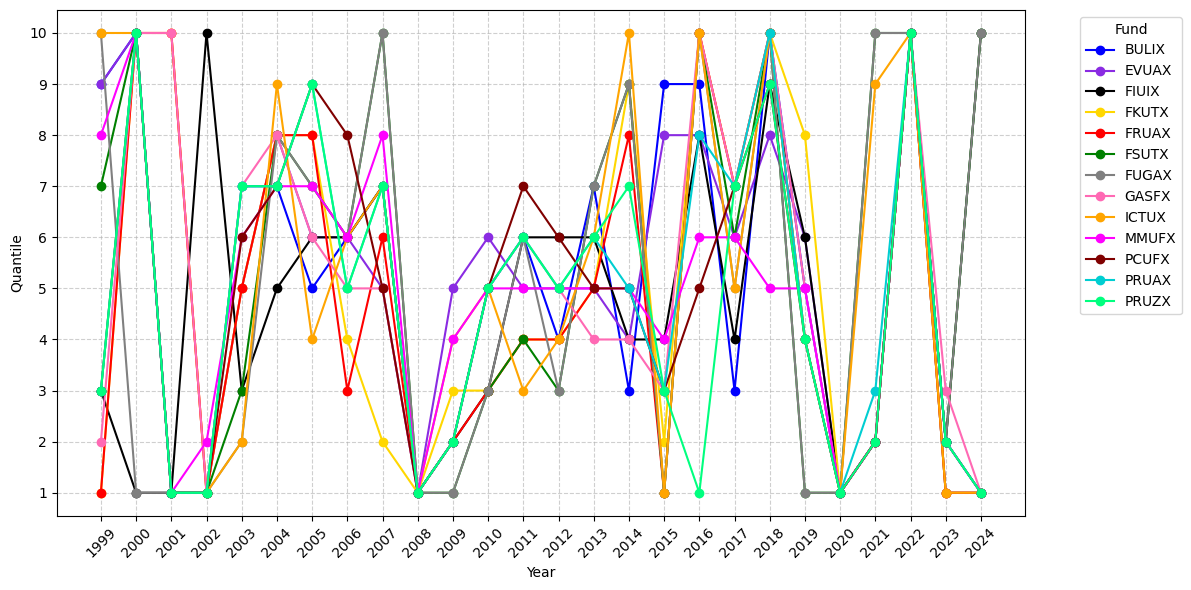

In [24]:
# Majority quantile per fund-year
majority_quantile = (
    Quart.groupby(["Fund", "Year"])["Quantile"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

# Prepare full list of years for X-axis ticks
years = sorted(majority_quantile["Year"].unique())

# Define colors for funds (13 distinct colors)
colors = [
    '#0000FF',  # Blue
    '#8A2BE2',  # Violet / BlueViolet
    '#000000',  # Black
    '#FFD700',  # Gold
    '#FF0000',  # Red
    '#008000',  # Green
    '#808080',  # Grey
    '#FF69B4',  # Hot Pink
    '#FFA500',  # Orange
    '#FF00FF',  # Magenta / Fuchsia
    '#800000',  # Maroon
    '#00CED1',  # Dark Turquoise
    '#00FF7F'   # Parrot Green / SpringGreen
]

# Map each fund to a color
funds = majority_quantile["Fund"].unique()
color_map = {fund: colors[i % len(colors)] for i, fund in enumerate(funds)}

# Plot
plt.figure(figsize=(12, 6))
for fund, group in majority_quantile.groupby("Fund"):
    plt.plot(
        group["Year"],
        group["Quantile"],
        marker='o',
        linestyle='-',
        label=fund,
        color=color_map[fund]
    )

plt.xticks(years, rotation=45)

plt.yticks(range(1, 11))
plt.xlabel("Year")
plt.ylabel("Quantile")
#plt.title("Majority Quantile per Fund-Year")
plt.legend(title="Fund", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
# Save as JPEG
plt.savefig("plots/jpg/Utilities.jpg", dpi=1200, bbox_inches="tight")

plt.show()

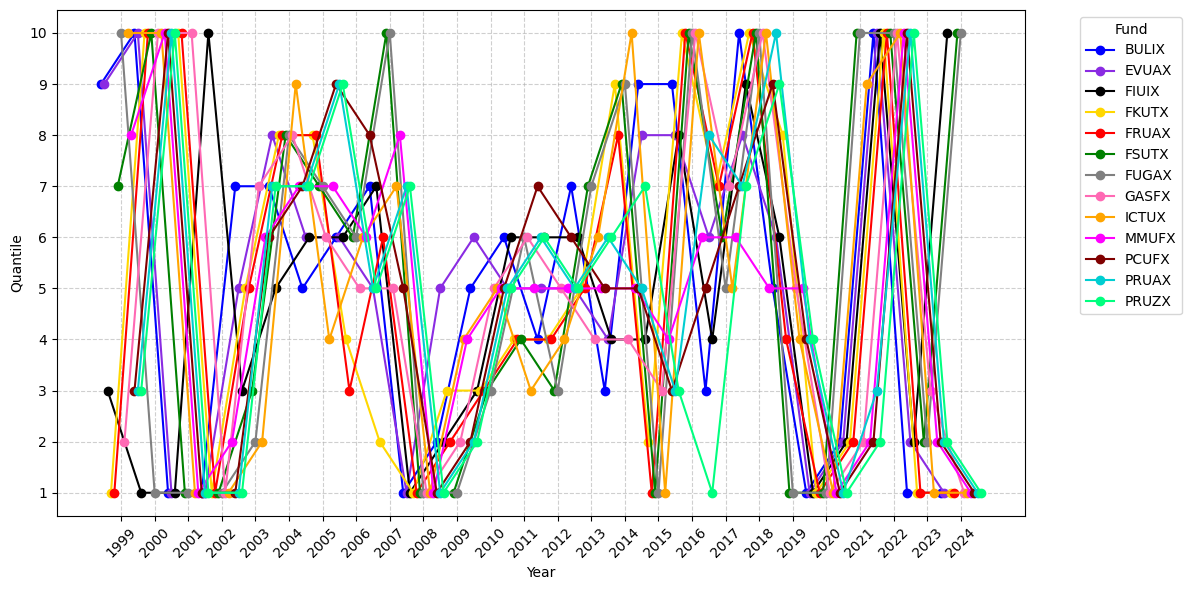

In [25]:
# Majority quantile per fund-year
majority_quantile = (
    Quart.groupby(["Fund", "Year"])["Quantile"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

# Prepare years and assign each fund a small X-offset
funds = majority_quantile["Fund"].unique()
offset_map = {fund: i * 0.1 - (len(funds) - 1) * 0.05 for i, fund in enumerate(funds)}

# Map each fund to a color
color_map = {fund: colors[i % len(colors)] for i, fund in enumerate(funds)}

plt.figure(figsize=(12, 6))

for fund, group in majority_quantile.groupby("Fund"):
    # Apply offset so lines don't overlap exactly
    x_vals = group["Year"] + offset_map[fund]
    plt.plot(
        x_vals,
        group["Quantile"],
        marker='o',
        linestyle='-',
        label=fund,
        color=color_map[fund]
    )

# Force ticks for all years, tilt labels
years = sorted(majority_quantile["Year"].unique())
plt.xticks(years, rotation=45)

plt.yticks(range(1, 11))
plt.xlabel("Year")
plt.ylabel("Quantile")
#plt.title("Majority Quantile per Fund-Year (With Jitter to Reduce Overlap)")
plt.legend(title="Fund", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("plots/jpg/Utilities_read.jpg", dpi=1200, bbox_inches="tight")
plt.show()

In [35]:
df = pd.read_csv(quantiles_uti)
df['Quantile'] = pd.to_numeric(df['Quantile'], errors='coerce')

Overall Hamming distance (all funds): 0.607

Diversification impact (largest drop = most diversification):
       H_without_fund  drop_in_diversification
Fund                                          
FIUIX        0.594406                 0.012596
ICTUX        0.599650                 0.007352
FUGAX        0.601399                 0.005603
MMUFX        0.601399                 0.005603
EVUAX        0.602564                 0.004438
FKUTX        0.604312                 0.002690
FSUTX        0.606643                 0.000359
PCUFX        0.608974                -0.001972
GASFX        0.609557                -0.002555
FRUAX        0.611888                -0.004886
BULIX        0.611888                -0.004886
PRUAX        0.618881                -0.011879
PRUZX        0.619464                -0.012462

Fund contributing the most diversification: FIUIX


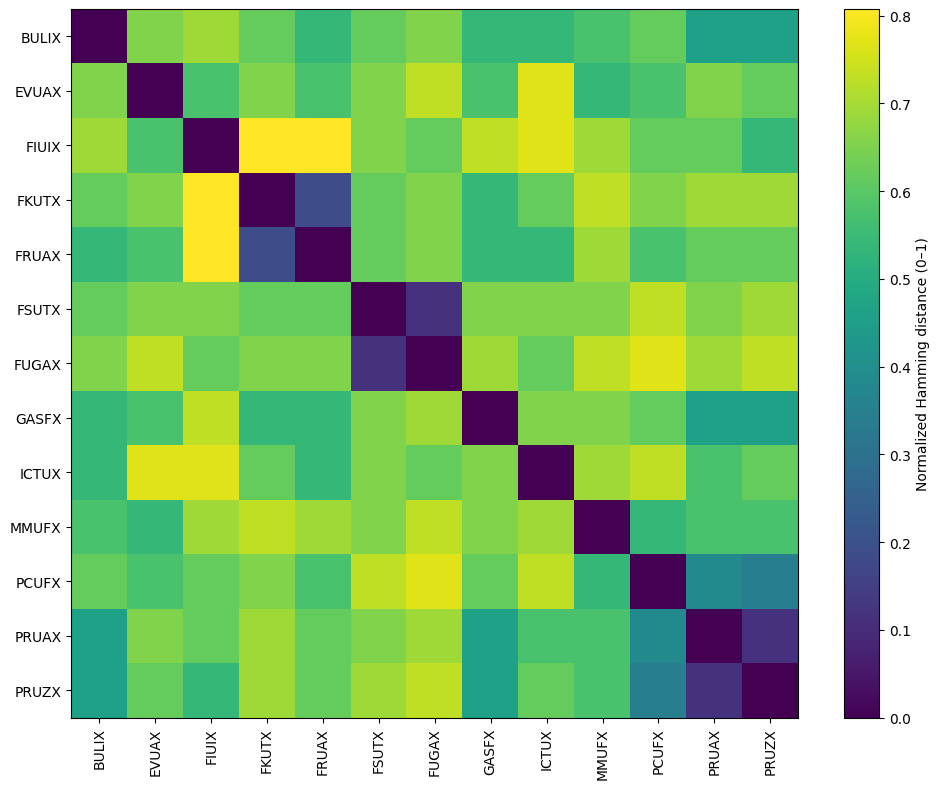

In [36]:
df['Quantile'] = pd.to_numeric(df['Quantile'], errors='coerce')

def mode_with_tiebreak(series):
    # mode() may return multiple values; pick the one whose value is closest to the median
    s = series.dropna().astype(float)
    if s.empty:
        return np.nan
    modes = s.mode()
    if len(modes) == 1:
        return int(modes.iloc[0])
    med = s.median()
    best = min(modes, key=lambda v: abs(v - med))
    return int(best)

yearly = (
    df.groupby(['Year', 'Fund'], as_index=False)['Quantile']
      .agg(yearly_label=mode_with_tiebreak)
)

trajectories = (
    yearly.pivot(index='Year', columns='Fund', values='yearly_label')
          .sort_index()
)
def hamming_distance(s1: pd.Series, s2: pd.Series, normalize=True):
    mask = s1.notna() & s2.notna()
    n = int(mask.sum())
    if n == 0:
        return np.nan, 0  # no overlap
    mismatches = int((s1[mask] != s2[mask]).sum())
    if normalize:
        return mismatches / n, n
    else:
        return mismatches, n

def avg_hamming_distance(trajs: pd.DataFrame, normalize=True):
    funds = list(trajs.columns)
    distances = []
    overlaps = []
    for f1, f2 in combinations(funds, 2):
        d, n = hamming_distance(trajs[f1], trajs[f2], normalize=normalize)
        if not np.isnan(d):
            distances.append(d)
            overlaps.append(n)
    if not distances:
        return np.nan
    return np.average(distances, weights=overlaps)

H_all = avg_hamming_distance(trajectories, normalize=True)
print(f"Overall Hamming distance (all funds): {H_all:.3f}")

impact = []
for fund in trajectories.columns:
    reduced = trajectories.drop(columns=fund)
    H_minus = avg_hamming_distance(reduced, normalize=True)
    impact.append({
        'Fund': fund,
        'H_without_fund': H_minus,
        'drop_in_diversification': H_all - H_minus
    })

impact_df = pd.DataFrame(impact).set_index('Fund').sort_values('drop_in_diversification', ascending=False)
print("\nDiversification impact (largest drop = most diversification):")
print(impact_df)

# Best fund to KEEP (removing it hurts diversification the most)
best = impact_df['drop_in_diversification'].idxmax()
print(f"\nFund contributing the most diversification: {best}")

funds = list(trajectories.columns)
M = pd.DataFrame(np.nan, index=funds, columns=funds)
Noverlap = pd.DataFrame(0, index=funds, columns=funds, dtype=int)

for f1, f2 in combinations(funds, 2):
    d, n = hamming_distance(trajectories[f1], trajectories[f2], normalize=True)
    M.loc[f1, f2] = M.loc[f2, f1] = d
    Noverlap.loc[f1, f2] = Noverlap.loc[f2, f1] = n

np.fill_diagonal(M.values, 0.0)

plt.figure(figsize=(10, 8))
im = plt.imshow(M.values, aspect='auto')
plt.xticks(range(len(funds)), funds, rotation=90)
plt.yticks(range(len(funds)), funds)
plt.colorbar(im, label='Normalized Hamming distance (0–1)')
#plt.title('Pairwise Hamming Distance (yearly labels)')
plt.tight_layout()
plt.savefig("plots/jpg/uti_hamming.jpg", dpi=1200, bbox_inches="tight")
plt.show()

In [43]:
df = pd.read_csv(quantiles_uti)
# Pivot the data: count of funds per quantile per year
quantile_counts = df.groupby(['Year', 'Quantile']).size().unstack(fill_value=0)
# Plot vertical stacked bar chart
quantile_counts

Quantile,1,2,3,4,5,6,7,8,9,10
Year,,,,,,,,,,
1999,360,387,391,302,275,280,277,293,351,334
2000,595,326,226,198,193,184,188,217,313,810
2001,616,379,284,197,227,194,209,218,350,563
2002,562,427,294,266,208,196,225,251,319,515
2003,144,334,397,362,386,400,416,326,303,182
2004,127,295,307,356,381,375,438,447,401,123
2005,190,223,244,389,386,442,455,413,345,163
2006,93,247,354,406,402,486,399,419,317,127
2007,191,290,317,290,377,390,434,399,320,242


In [ ]:
ax = quantile_counts.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab10')
plt.xlabel("Year")
plt.ylabel("Number of Counts")
#plt.title("Funds by Quantile per Year")
plt.legend(title="Quantile", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("plots/jpg/uti_stack.jpg", dpi=1200, bbox_inches="tight")

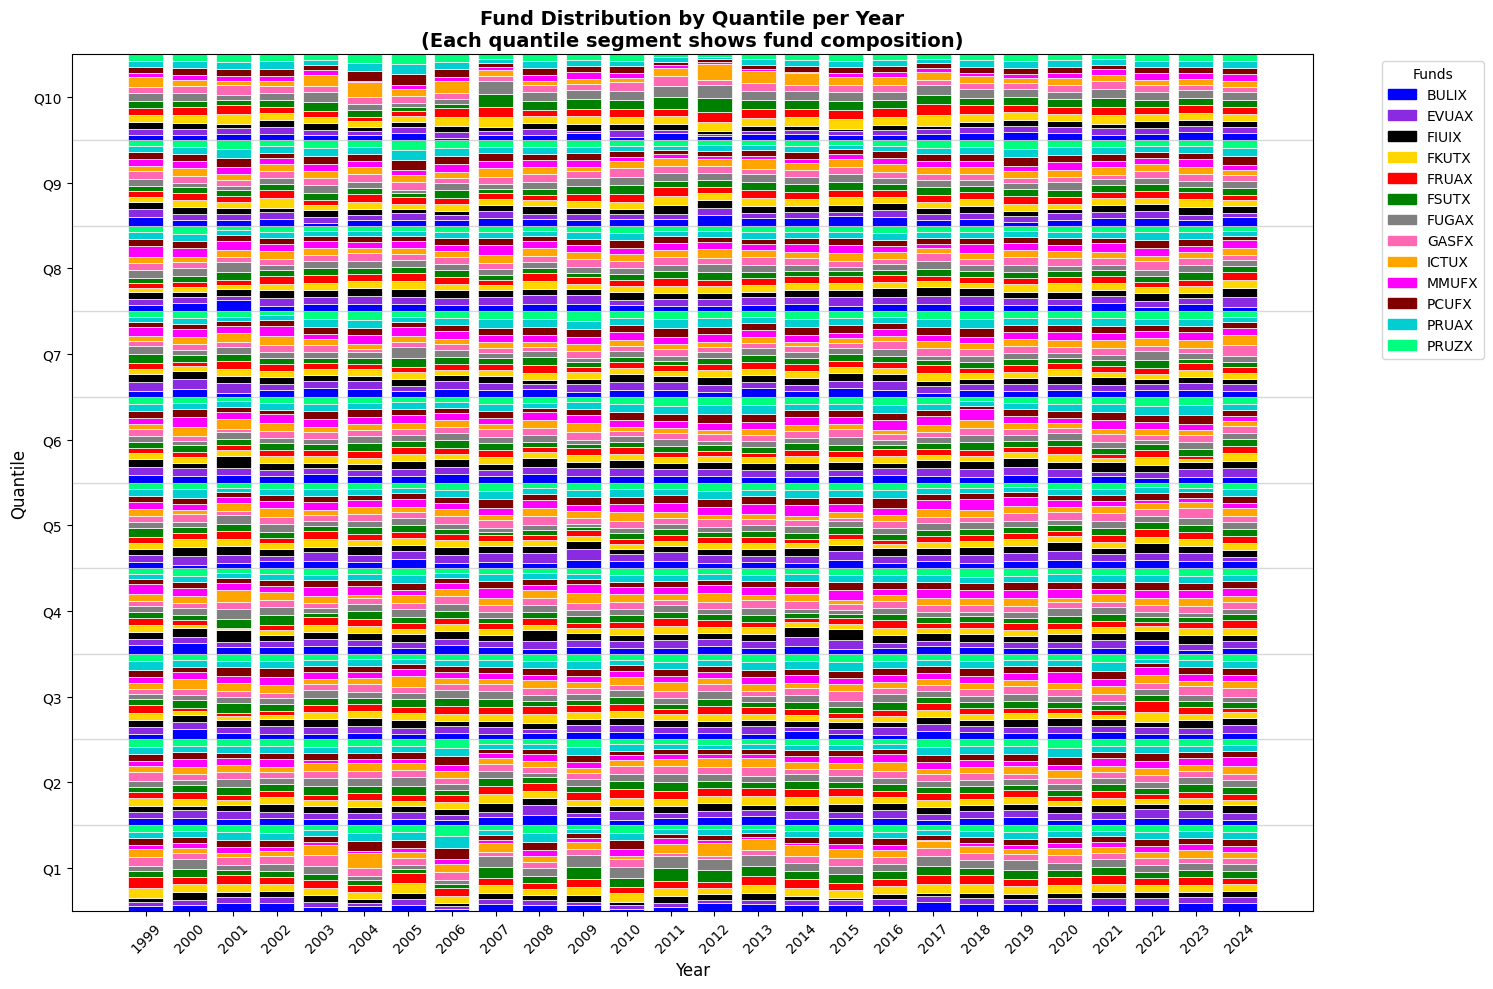

In [38]:
# Count days each fund spent in each quantile per year
daily_counts = df.groupby(['Year', 'Fund', 'Quantile']).size().reset_index(name='Days')

# Get unique values
years = sorted(df['Year'].unique())
funds = sorted(df['Fund'].unique())
quantiles = sorted(df['Quantile'].unique())

fund_colors = dict(zip(funds, colors))

# Create the plot
fig, ax = plt.subplots(figsize=(15, 10))

x_positions = np.arange(len(years))
bar_width = 0.8

# For each year (bar), stack quantiles from bottom to top
for year_idx, year in enumerate(years):
    bottom_pos = 0
    
    # Stack quantiles from 1 to 10
    for quantile in quantiles:
        # Get all funds in this quantile for this year
        year_quantile_data = daily_counts[
            (daily_counts['Year'] == year) & 
            (daily_counts['Quantile'] == quantile)
        ]
        
        # Calculate total days for this quantile
        total_days_in_quantile = year_quantile_data['Days'].sum()
        
        if total_days_in_quantile > 0:
            # Calculate proportional height for each fund within this quantile
            fund_start = bottom_pos
            
            for _, row in year_quantile_data.iterrows():
                fund = row['Fund']
                days = row['Days']
                
                # Calculate proportional height based on days
                proportion = days / total_days_in_quantile
                segment_height = proportion
                
                # Draw this fund's segment within the quantile
                ax.bar(year_idx, segment_height, bottom=fund_start, 
                       color=fund_colors[fund], alpha=1.0,
                       edgecolor='white', linewidth=0.5, width=bar_width)
                
                fund_start += segment_height
        
        # Move to next quantile position
        bottom_pos += 1

# Formatting
ax.set_title('Fund Distribution by Quantile per Year\n(Each quantile segment shows fund composition)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Quantile', fontsize=12)
ax.set_xticks(x_positions)
ax.set_xticklabels(years, rotation=45)

# Set Y-axis to show quantiles
ax.set_yticks(np.arange(0.5, len(quantiles) + 0.5, 1))
ax.set_yticklabels([f'Q{q}' for q in quantiles])
ax.set_ylim(0, len(quantiles))

# Add horizontal grid lines to separate quantiles
for i in range(1, len(quantiles)):
    ax.axhline(y=i, color='gray', linestyle='-', alpha=0.3, linewidth=1)

# Create legend for funds
handles = [plt.Rectangle((0,0),1,1, color=fund_colors[fund], alpha=1.0) for fund in funds]
ax.legend(handles, funds, title='Funds', bbox_to_anchor=(1.05, 1), 
          loc='upper left', ncol=1, fontsize=10)

plt.tight_layout()
plt.show()

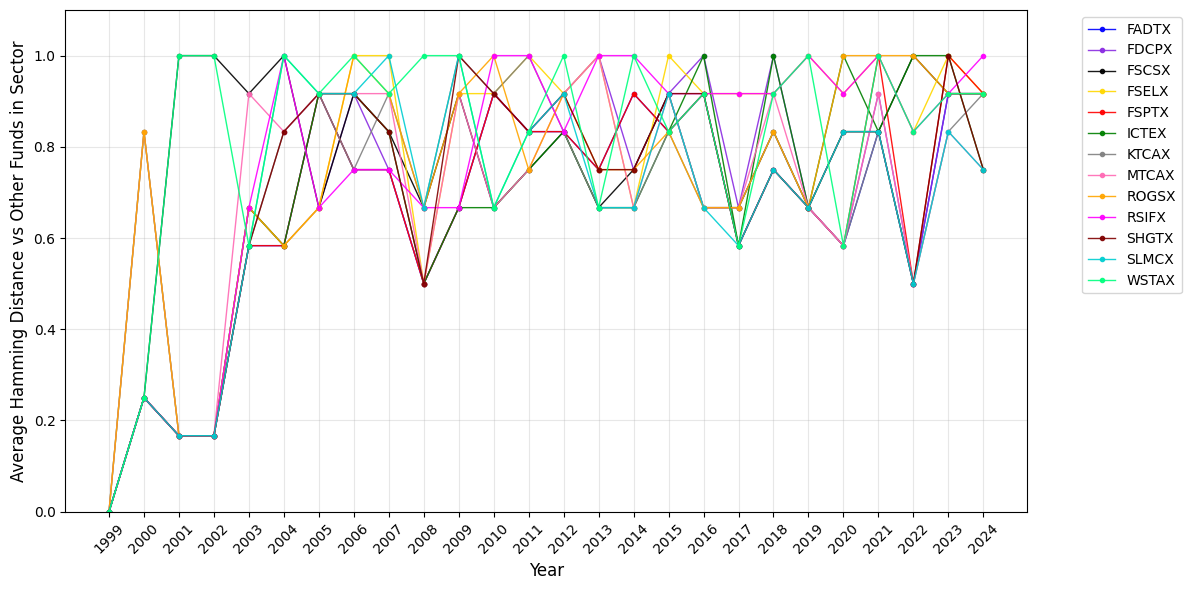

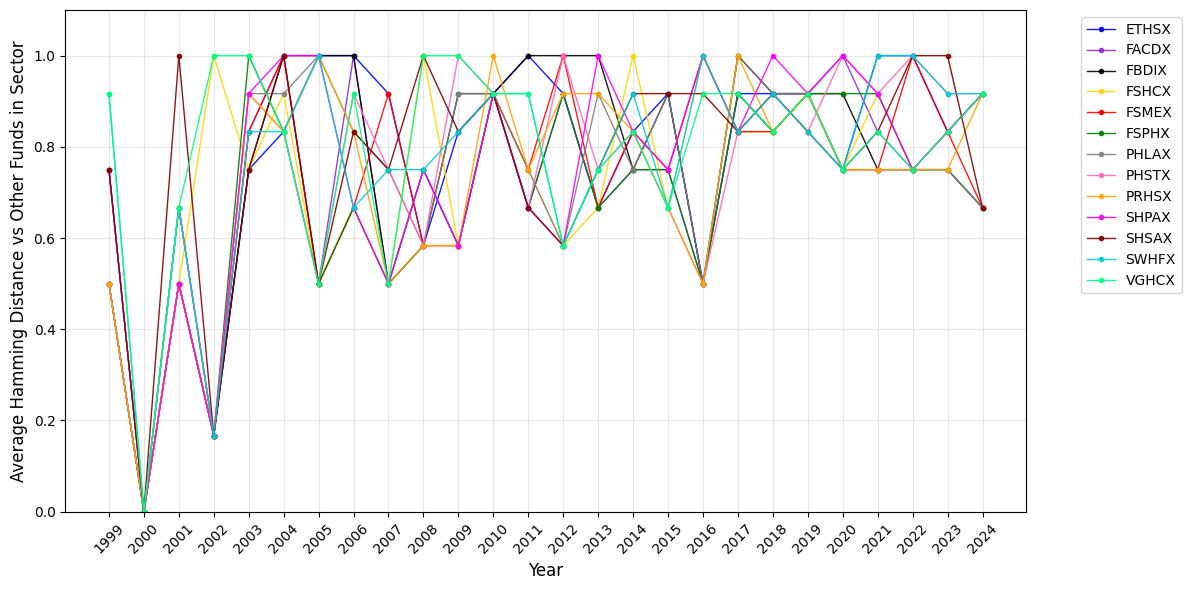

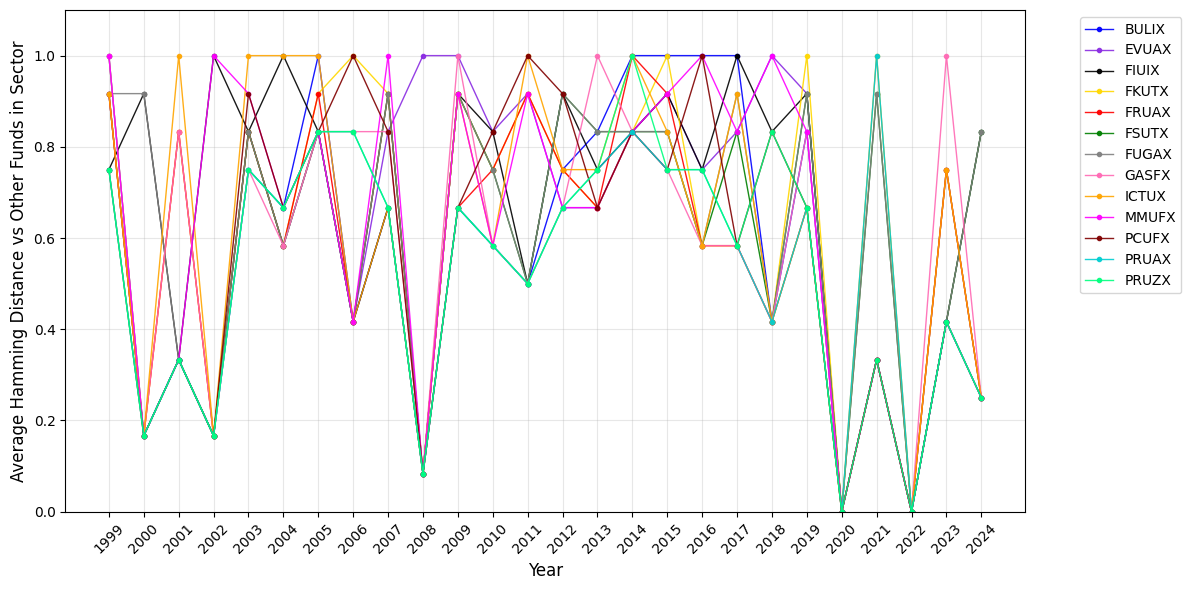

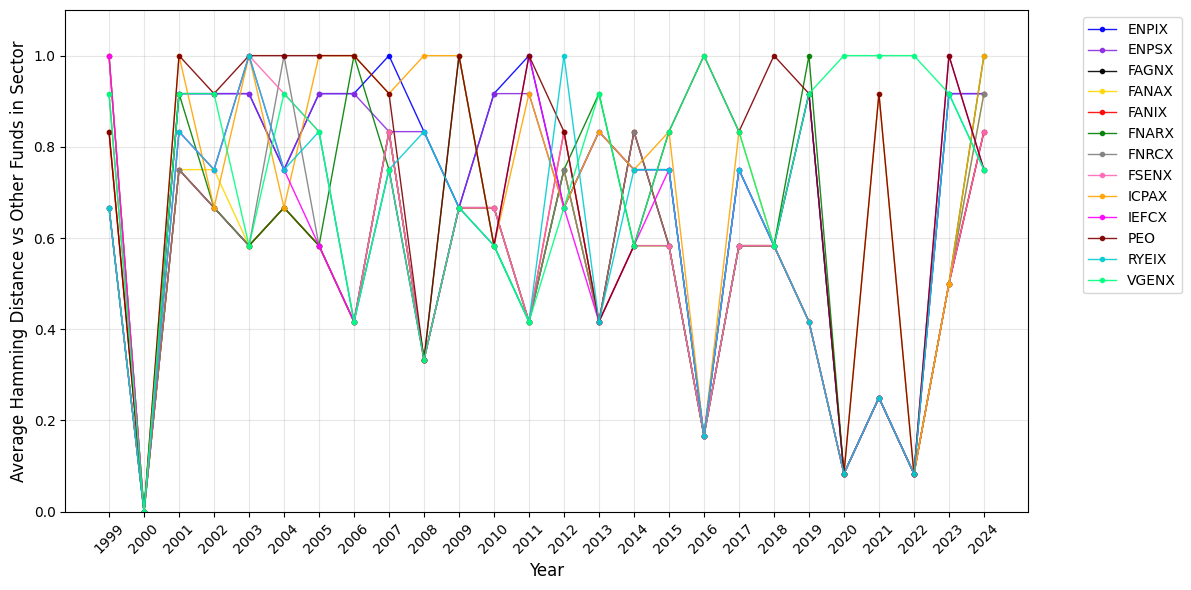

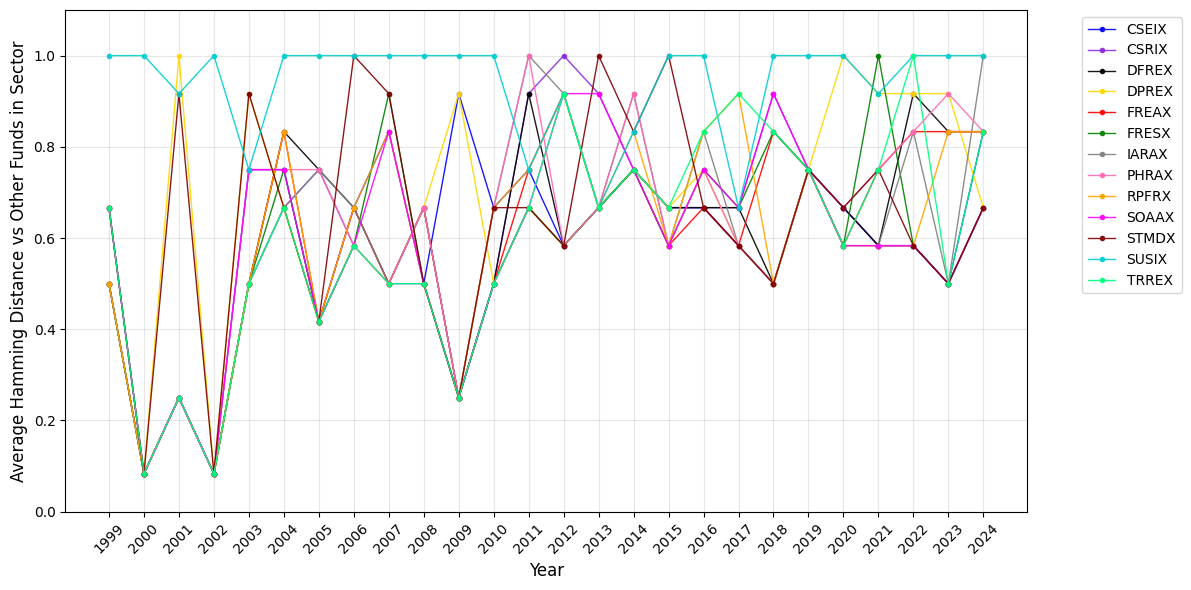

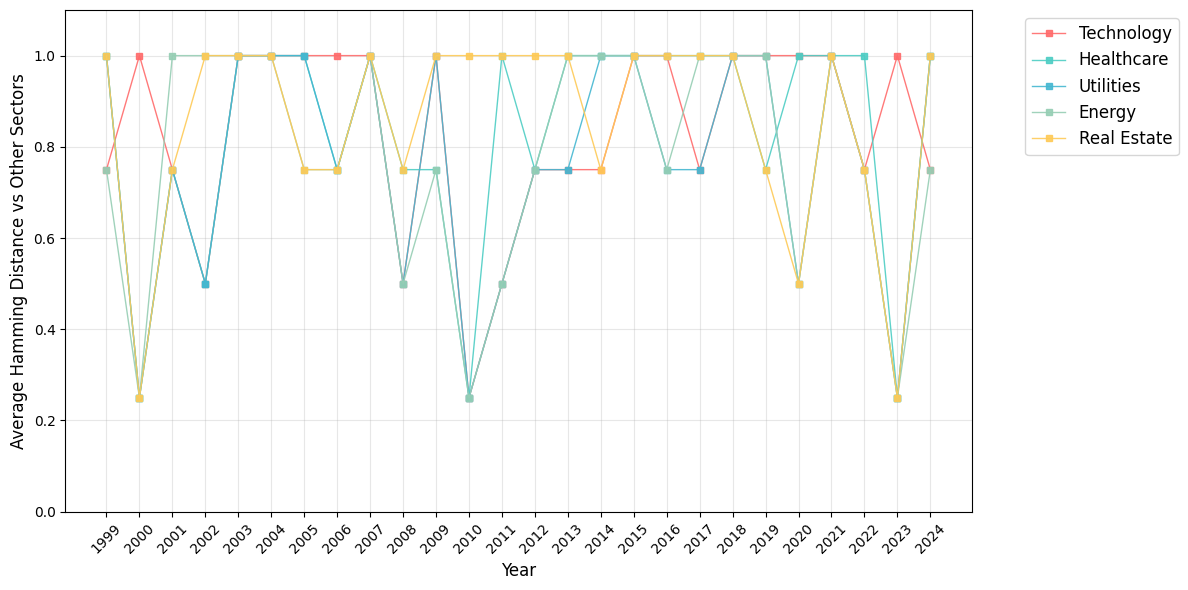

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

# Define your sector files
sector_files = {
    'Technology': quantiles_tech,      
    'Healthcare': quantiles_hc, 
    'Utilities': quantiles_uti,       
    'Energy': quantiles_e,         
    'Real Estate': quantiles_RE      
}

# Load and combine all sector files
dfs = []
sector_data = {}  # Store individual sector dataframes
for sector_name, filename in sector_files.items():
    try:
        # If it's a filename string, read the CSV
        if isinstance(filename, str):
            sector_df = pd.read_csv(filename)
        else:
            # If it's already a DataFrame, copy it
            sector_df = filename.copy()
        
        sector_df['Sector'] = sector_name  # Add sector column
        sector_data[sector_name] = sector_df  # Store individual sector data
        dfs.append(sector_df)
    except Exception as e:
        print(f"Error loading {sector_name}: {e}")

# Combine all dataframes for overall analysis
df = pd.concat(dfs, ignore_index=True)

# Colors for sectors in the final plot
sector_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57']

def mode_with_tiebreak(series):
    s = series.dropna().astype(float)
    if s.empty:
        return np.nan
    modes = s.mode()
    if len(modes) == 1:
        return int(modes.iloc[0])
    med = s.median()
    best = min(modes, key=lambda v: abs(v - med))
    return int(best)

def calculate_fund_hamming_distance(fund_data, all_other_funds_data):
    """Calculate average Hamming distance between one fund and all others for a given year"""
    distances = []
    
    for other_fund, other_quantile in all_other_funds_data.items():
        if pd.notna(fund_data) and pd.notna(other_quantile):
            distance = 0 if fund_data == other_quantile else 1
            distances.append(distance)
    
    return np.mean(distances) if distances else np.nan

# Convert Quantile to numeric for all data
df['Quantile'] = pd.to_numeric(df['Quantile'], errors='coerce')

sector_names = list(sector_data.keys())

for i, (sector_name, sector_df) in enumerate(sector_data.items()):
    # Create individual plot for this sector
    plt.figure(figsize=(12, 6))
    
    # Convert quantile to numeric for this sector
    sector_df['Quantile'] = pd.to_numeric(sector_df['Quantile'], errors='coerce')
    
    # Get yearly labels for each fund in this sector
    sector_yearly = (
        sector_df.groupby(['Year', 'Fund'], as_index=False)['Quantile']
                 .agg(yearly_label=mode_with_tiebreak)
    )
    
    # Create trajectories for this sector
    sector_trajectories = (
        sector_yearly.pivot(index='Year', columns='Fund', values='yearly_label')
                     .sort_index()
    )
    
    years = sector_trajectories.index
    sector_funds = sector_trajectories.columns
    
    # Plot each fund in this sector
    for j, fund in enumerate(sector_funds):
        fund_hamming_distances = []
        
        for year in years:
            # Get this fund's quantile for this year
            fund_quantile = sector_trajectories.loc[year, fund]
            
            # Get all other funds' quantiles in this sector for this year
            other_funds = {f: sector_trajectories.loc[year, f] for f in sector_funds if f != fund}
            
            # Calculate average hamming distance to all other funds in this sector
            hamming_dist = calculate_fund_hamming_distance(fund_quantile, other_funds)
            fund_hamming_distances.append(hamming_dist)
        
        # Use colors cyclically if more than 13 funds
        color_idx = j % len(colors)
        
        # Plot this fund's line
        plt.plot(years, fund_hamming_distances, marker='o', linewidth=1, 
                markersize=3, color=colors[color_idx], label=fund, alpha=0.9)
    
    #plt.title(f'{sector_name} Sector - Fund Diversification Analysis\n' f'({len(sector_funds)} funds within sector)', fontweight='bold', fontsize=14)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Average Hamming Distance vs Other Funds in Sector', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.1)
    plt.xticks(years, rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.savefig(f"plots/jpg/AHD_{sector_name}.jpg", dpi=1200, bbox_inches="tight")
    plt.show()

plt.figure(figsize=(12, 6))

# Get yearly labels for overall analysis
yearly = (
    df.groupby(['Year', 'Fund', 'Sector'], as_index=False)['Quantile']
      .agg(yearly_label=mode_with_tiebreak)
)

# Calculate sector-level yearly labels (mode of funds in each sector)
sector_yearly_overall = []
for year in sorted(df['Year'].unique()):
    year_data = yearly[yearly['Year'] == year]
    for sector in sector_names:
        sector_year_data = year_data[year_data['Sector'] == sector]
        if not sector_year_data.empty:
            sector_label = mode_with_tiebreak(sector_year_data['yearly_label'])
            sector_yearly_overall.append({
                'Year': year,
                'Sector': sector,
                'yearly_label': sector_label
            })

sector_yearly_df = pd.DataFrame(sector_yearly_overall)

# Create sector trajectories
sector_trajectories_overall = (
    sector_yearly_df.pivot(index='Year', columns='Sector', values='yearly_label')
                    .sort_index()
)

years = sector_trajectories_overall.index

# Plot each sector line
for i, sector in enumerate(sector_names):
    sector_hamming_distances = []
    
    for year in years:
        # Get this sector's quantile for this year
        sector_quantile = sector_trajectories_overall.loc[year, sector]
        
        # Get all other sectors' quantiles for this year
        other_sectors = {s: sector_trajectories_overall.loc[year, s] 
                        for s in sector_names if s != sector}
        
        # Calculate average hamming distance to all other sectors
        hamming_dist = calculate_fund_hamming_distance(sector_quantile, other_sectors)
        sector_hamming_distances.append(hamming_dist)
    
    # Plot this sector's line
    plt.plot(years, sector_hamming_distances, marker='s', linewidth=1, 
            markersize=4, color=sector_colors[i], label=sector, alpha=0.9)

#plt.title('Inter-Sector Diversification Analysis\n' '(How Different Each Sector is from Others)', fontweight='bold', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Hamming Distance vs Other Sectors', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)
plt.xticks(years, rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.savefig("plots/jpg/AHD_intersector.jpg", dpi=1200, bbox_inches="tight")
plt.show()
